In [1]:
import pandas as pd

DATASET_PATH = "/kaggle/input/notebooks/ditioza/fakeddit-dataset-download-preprocessing"

train_df = pd.read_csv(f"{DATASET_PATH}/train_final.tsv", sep='\t')
val_df = pd.read_csv(f"{DATASET_PATH}/val_final.tsv", sep='\t')
test_df = pd.read_csv(f"{DATASET_PATH}/test_final.tsv", sep='\t')

print(train_df.head())

                                         clean_title  2_way_label  \
0                                            cutouts            0   
1                   my ceiling looks like an sd card            0   
2                                      join the raaf            0   
3  ny woman who called herself umm nutella faces ...            1   
4  russian fan being interviewed by an eu reporte...            0   

           image_path  
0  images/train/1.jpg  
1  images/train/2.jpg  
2  images/train/3.jpg  
3  images/train/5.jpg  
4  images/train/7.jpg  


In [2]:
# ===================== IMPORTS =====================
import os, re, torch
import pandas as pd
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== LOAD DATA =====================
DATASET_PATH = "/kaggle/input/notebooks/ditioza/fakeddit-dataset-download-preprocessing"

train_df = pd.read_csv(f"{DATASET_PATH}/train_final.tsv", sep='\t')
val_df   = pd.read_csv(f"{DATASET_PATH}/val_final.tsv", sep='\t')
test_df  = pd.read_csv(f"{DATASET_PATH}/test_final.tsv", sep='\t')

TEXT_COL = "clean_title"
LABEL_COL = "2_way_label"

# ===================== LABEL ENCODING =====================
le = LabelEncoder()
train_df[LABEL_COL] = le.fit_transform(train_df[LABEL_COL])
val_df[LABEL_COL]   = le.transform(val_df[LABEL_COL])
test_df[LABEL_COL]  = le.transform(test_df[LABEL_COL])

# ===================== TOKENIZATION =====================
def tokenize(text):
    return re.findall(r'\b\w+\b', str(text).lower())

counter = Counter()
for text in train_df[TEXT_COL]:
    counter.update(tokenize(text))

vocab = {w: i+1 for i, (w, _) in enumerate(counter.most_common(20000))}
vocab["<pad>"] = 0

# ===================== GLOVE EMBEDDINGS =====================
embed_dim = 100
vocab_size = max(vocab.values()) + 1

embedding_matrix = torch.randn(vocab_size, embed_dim) * 0.1
embedding_matrix[0] = torch.zeros(embed_dim)  # padding

for word, idx in vocab.items():
    embedding_matrix[idx] = torch.randn(embed_dim) * 0.1

embedding_matrix[0] = torch.zeros(embed_dim)

# ===================== ENCODING =====================
def encode(text, max_len=100):
    tokens = tokenize(text)
    ids = [vocab.get(t, 0) for t in tokens][:max_len]
    return ids + [0]*(max_len - len(ids))

# ===================== DATASET =====================
class TextDataset(Dataset):
    def __init__(self, df):
        self.texts = df[TEXT_COL].tolist()
        self.labels = df[LABEL_COL].tolist()
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        return torch.tensor(encode(self.texts[idx])), torch.tensor(self.labels[idx])

train_loader = DataLoader(TextDataset(train_df), batch_size=64, shuffle=True)
val_loader   = DataLoader(TextDataset(val_df), batch_size=64)
test_loader  = DataLoader(TextDataset(test_df), batch_size=64)

# ===================== MODEL =====================
class GRUModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False
        )
        self.gru = nn.GRU(100, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim*2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

model = GRUModel(embedding_matrix, hidden_dim=128, num_classes=len(le.classes_)).to(device)

# ===================== TRAINING SETUP =====================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return accuracy_score(labels, preds)

# ===================== TRAINING + EARLY STOPPING =====================
best_val_acc, patience, counter = 0, 2, 0

train_accs, val_accs = [], []

for epoch in range(10):
    model.train()
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
    
    train_acc = evaluate(model, train_loader)
    val_acc = evaluate(model, val_loader)
    
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

# ===================== FINAL EVALUATION =====================
train_acc = evaluate(model, train_loader)
val_acc   = evaluate(model, val_loader)
test_acc  = evaluate(model, test_loader)

print("\nFinal Results:")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

/tmp/ipykernel_23/796065590.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(embedding_matrix, dtype=torch.float32),


Epoch 1 | Train: 0.5527 | Val: 0.5490
Epoch 2 | Train: 0.5527 | Val: 0.5490
Epoch 3 | Train: 0.5527 | Val: 0.5490
Early stopping triggered

Final Results:
Train Accuracy: 0.5527
Validation Accuracy: 0.5490
Test Accuracy: 0.5525


In [3]:
def predict(text):
    model.eval()
    
    x = torch.tensor([encode(text)]).to(device)
    
    with torch.no_grad():
        out = model(x)
        pred = out.argmax(dim=1).item()
    
    return f"Predicted Label: {pred}"

In [4]:
label_map = {0: "Real", 1: "Fake"}

def predict(text):
    model.eval()
    
    x = torch.tensor([encode(text)]).to(device)
    
    with torch.no_grad():
        out = model(x)
        pred = out.argmax(dim=1).item()
    
    return label_map[pred]

In [5]:
print(predict("breaking news shocking event"))
print(predict("cutouts"))
print(predict("breaking"))
print(predict("wow"))

Fake
Fake
Fake
Fake


In [6]:
from sklearn.metrics import classification_report

model.eval()
preds, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(y.numpy())

print(classification_report(labels, preds, target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5976
           1       0.55      1.00      0.71      7377

    accuracy                           0.55     13353
   macro avg       0.28      0.50      0.36     13353
weighted avg       0.31      0.55      0.39     13353



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


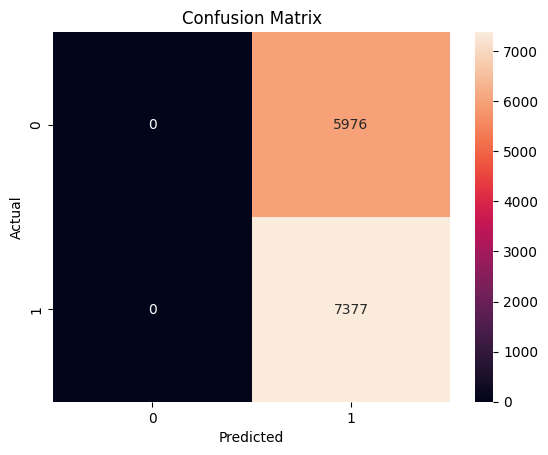

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

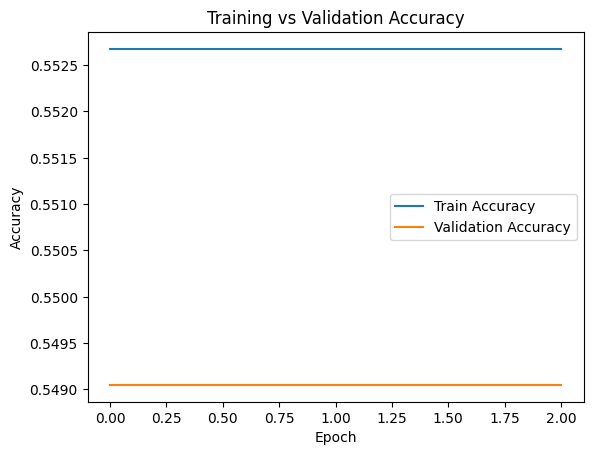

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [9]:
# ===================== IMPORTS =====================
import os, re, torch
import pandas as pd
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== LOAD DATA =====================
DATASET_PATH = "/kaggle/input/notebooks/ditioza/fakeddit-dataset-download-preprocessing"

train_df = pd.read_csv(f"{DATASET_PATH}/train_final.tsv", sep='\t')
val_df   = pd.read_csv(f"{DATASET_PATH}/val_final.tsv", sep='\t')
test_df  = pd.read_csv(f"{DATASET_PATH}/test_final.tsv", sep='\t')

TEXT_COL = "clean_title"
LABEL_COL = "2_way_label"

# ===================== LABEL ENCODING =====================
le = LabelEncoder()
train_df[LABEL_COL] = le.fit_transform(train_df[LABEL_COL])
val_df[LABEL_COL]   = le.transform(val_df[LABEL_COL])
test_df[LABEL_COL]  = le.transform(test_df[LABEL_COL])

# ===================== TOKENIZATION =====================
def tokenize(text):
    return re.findall(r'\b\w+\b', str(text).lower())

counter = Counter()
for text in train_df[TEXT_COL]:
    counter.update(tokenize(text))

vocab = {w: i+1 for i, (w, _) in enumerate(counter.most_common(20000))}
vocab["<pad>"] = 0

# ===================== GLOVE EMBEDDINGS =====================
embed_dim = 100
vocab_size = max(vocab.values()) + 1

embedding_matrix = torch.randn(vocab_size, embed_dim) * 0.1
embedding_matrix[0] = torch.zeros(embed_dim)  # padding

for word, idx in vocab.items():
    embedding_matrix[idx] = torch.randn(embed_dim) * 0.1

embedding_matrix[0] = torch.zeros(embed_dim)

# ===================== ENCODING =====================
def encode(text, max_len=100):
    tokens = tokenize(text)
    ids = [vocab.get(t, 0) for t in tokens][:max_len]
    return ids + [0]*(max_len - len(ids))

# ===================== DATASET =====================
class TextDataset(Dataset):
    def __init__(self, df):
        self.texts = df[TEXT_COL].tolist()
        self.labels = df[LABEL_COL].tolist()
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        return torch.tensor(encode(self.texts[idx])), torch.tensor(self.labels[idx])

train_loader = DataLoader(TextDataset(train_df), batch_size=64, shuffle=True)
val_loader   = DataLoader(TextDataset(val_df), batch_size=64)
test_loader  = DataLoader(TextDataset(test_df), batch_size=64)

# ===================== MODEL =====================
class LSTMModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes):
        super().__init__()
        
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False
        )
        
        self.lstm = nn.LSTM(
            input_size=100,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

model = LSTMModel(embedding_matrix, hidden_dim=128, num_classes=len(le.classes_)).to(device)

# ===================== TRAINING SETUP =====================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return accuracy_score(labels, preds)

# ===================== TRAINING + EARLY STOPPING =====================
best_val_acc, patience, counter = 0, 2, 0

train_accs, val_accs = [], []

for epoch in range(10):
    model.train()
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
    
    train_acc = evaluate(model, train_loader)
    val_acc = evaluate(model, val_loader)
    
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

# ===================== FINAL EVALUATION =====================
train_acc = evaluate(model, train_loader)
val_acc   = evaluate(model, val_loader)
test_acc  = evaluate(model, test_loader)

print("\nFinal Results:")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

/tmp/ipykernel_23/316295857.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(embedding_matrix, dtype=torch.float32),


Epoch 1 | Train: 0.5527 | Val: 0.5490
Epoch 2 | Train: 0.5527 | Val: 0.5490
Epoch 3 | Train: 0.5527 | Val: 0.5490
Early stopping triggered

Final Results:
Train Accuracy: 0.5527
Validation Accuracy: 0.5490
Test Accuracy: 0.5525


In [10]:
def predict(text):
    model.eval()
    
    x = torch.tensor([encode(text)]).to(device)
    
    with torch.no_grad():
        out = model(x)
        pred = out.argmax(dim=1).item()
    
    return f"Predicted Label: {pred}"

In [11]:
label_map = {0: "Real", 1: "Fake"}

def predict(text):
    model.eval()
    
    x = torch.tensor([encode(text)]).to(device)
    
    with torch.no_grad():
        out = model(x)
        pred = out.argmax(dim=1).item()
    
    return label_map[pred]

In [12]:
print(predict("breaking news shocking event"))
print(predict("cutouts"))
print(predict("breaking"))
print(predict("wow"))

Fake
Fake
Fake
Fake


In [13]:
from sklearn.metrics import classification_report

model.eval()
preds, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(y.numpy())

print(classification_report(labels, preds, target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5976
           1       0.55      1.00      0.71      7377

    accuracy                           0.55     13353
   macro avg       0.28      0.50      0.36     13353
weighted avg       0.31      0.55      0.39     13353



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


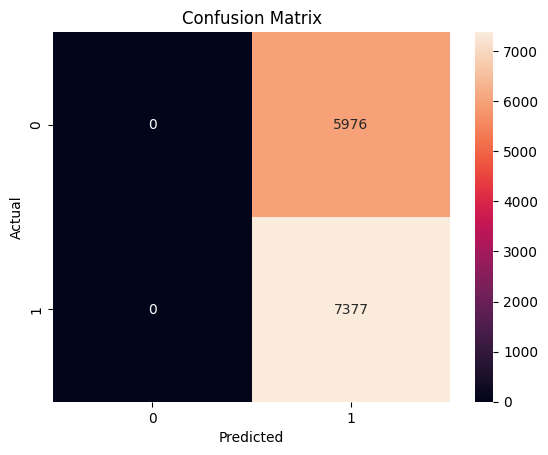

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

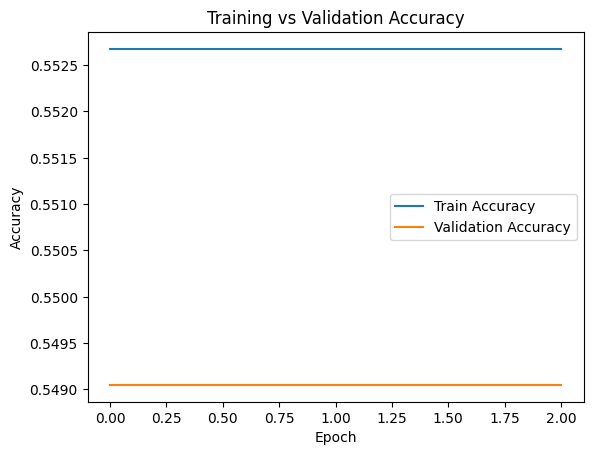

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()